# Week 3 - Ames Housing: Cleaning and Outlier Detection

This notebook covers the **Cleaning Sprint** for the Ames Housing dataset. The main focus this week is to understand the missing values, decide how to handle them, and look for unusual observations using boxplots and Z-scores.

The goal is not to make the data look perfect. It is to make sensible cleaning decisions and keep a record of why those decisions were made.

## 1. Import the libraries and load the data

The project data may be kept as a CSV file. The code below checks for `AmesHousing_Uncleaned.csv` first. If that file is not present, it also accepts the original Excel file so the notebook can still be run without changing the rest of the code.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if os.path.exists("AmesHousing_Uncleaned.csv"):
    df = pd.read_csv("AmesHousing_Uncleaned.csv")
    print("Loaded AmesHousing_Uncleaned.csv")
elif os.path.exists("AmesHousing_Uncleaned.xlsx"):
    df = pd.read_excel("AmesHousing_Uncleaned.xlsx")
    print("Loaded AmesHousing_Uncleaned.xlsx")
else:
    raise FileNotFoundError("Place AmesHousing_Uncleaned.csv (or AmesHousing_Uncleaned.xlsx) in the same folder as this notebook.")

print("Shape:", df.shape)

Loaded AmesHousing_Uncleaned.xlsx
Shape: (3130, 82)


## 2. First look at the dataset

Before changing anything, it is useful to see the first few rows, the column types, and the size of the dataset. This gives us a reference point for the cleaning work.

In [6]:
display(df.head())

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,NaN,RL,NaN,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20.0,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20.0,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20.0,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60.0,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Rows: 3130
Columns: 82
<class 'pandas.DataFrame'>
RangeIndex: 3130 entries, 0 to 3129
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            3130 non-null   int64  
 1   PID              3130 non-null   int64  
 2   MS SubClass      3010 non-null   float64
 3   MS Zoning        3130 non-null   str    
 4   Lot Frontage     2511 non-null   float64
 5   Lot Area         3130 non-null   int64  
 6   Street           3130 non-null   str    
 7   Alley            203 non-null    str    
 8   Lot Shape        3130 non-null   str    
 9   Land Contour     3130 non-null   str    
 10  Utilities        3130 non-null   str    
 11  Lot Config       3130 non-null   str    
 12  Land Slope       3130 non-null   str    
 13  Neighborhood     3130 non-null   str    
 14  Condition 1      3130 non-null   str    
 15  Condition 2      3130 non-null   str    
 16  Bldg Type        3130 non-null   str    
 17  Ho

## 3. Check for missing values

The first cleaning task is to find where values are missing. Looking at both the count and the percentage is more useful than looking at the count alone because the columns all have the same number of rows.

In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().sum() / len(df) * 100).round(2)
})

missing = missing[missing["Missing Values"] > 0].sort_values(
    "Missing Values", ascending=False
)

display(missing)

,Missing Values,Missing Percentage
Pool QC,3117,99.58
Misc Feature,3012,96.23
Alley,2927,93.51
Fence,2517,80.42
Mas Vnr Type,1892,60.45
Fireplace Qu,1523,48.66
Lot Frontage,619,19.78
Garage Finish,167,5.34
Garage Qual,167,5.34
Garage Cond,167,5.34


## 4. Decide what the missing values mean

A missing value does not always mean that someone forgot to enter the data. In this dataset, several missing categorical values actually mean that the house does not have that feature. For example, a missing `Pool QC` means there is no pool, not that the pool quality was forgotten.

For those columns, replacing the missing value with `None` keeps that information instead of throwing it away.

For numerical columns, the strategy depends on the variable. For example, `Lot Frontage` can reasonably use its median because it is a continuous measurement and housing data can be skewed by unusually large properties.

In [8]:
# Missing categorical values that represent the absence of a feature
no_feature_cols = [
    "Alley", "Mas Vnr Type", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure",
    "BsmtFin Type 1", "BsmtFin Type 2", "Fireplace Qu", "Garage Type",
    "Garage Finish", "Garage Qual", "Garage Cond", "Pool QC", "Fence",
    "Misc Feature"
]

for col in no_feature_cols:
    if col in df.columns:
        df[col] = df[col].fillna("None")

# Numerical measurements where a missing value means the feature is absent
zero_if_absent = [
    "Mas Vnr Area", "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF",
    "Total Bsmt SF", "Bsmt Full Bath", "Bsmt Half Bath", "Garage Cars",
    "Garage Area"
]

for col in zero_if_absent:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Lot Frontage is a numerical measurement, so use the median.
if "Lot Frontage" in df.columns:
    df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())

# If Garage Year is missing because there is no garage, use 0 as a clear marker.
if "Garage Yr Blt" in df.columns:
    df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(0)

print("Main missing-value replacements have been applied.")

Main missing-value replacements have been applied.


## 5. Check what is still missing

After the first cleaning pass, we check the dataset again. Any remaining missing values should be small enough to investigate rather than filling everything automatically.

In [9]:
remaining_missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().sum() / len(df) * 100).round(2)
})

remaining_missing = remaining_missing[
    remaining_missing["Missing Values"] > 0
].sort_values("Missing Values", ascending=False)

display(remaining_missing)

,Missing Values,Missing Percentage
MS SubClass,120,3.83
Electrical,1,0.03


If a few numerical values are still missing, using the median is a reasonable final step for this exploratory project. The median is less affected by extreme house prices and unusually large measurements than the mean.

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if df[col].isna().any():
        mode = df[col].mode()
        if not mode.empty:
            df[col] = df[col].fillna(mode.iloc[0])

print("Remaining missing values:", int(df.isna().sum().sum()))

Remaining missing values: 0


C:\Users\phps3\AppData\Local\Temp\ipykernel_25988\2622018866.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


## 6. Outlier detection with boxplots

The next step is to look for unusually high or low values. Boxplots are useful because they show the middle 50% of the data and make extreme observations easy to spot.

An outlier is not automatically a mistake. A large house or an expensive house can be a genuine observation, so these plots are mainly used to identify records that deserve a closer look.

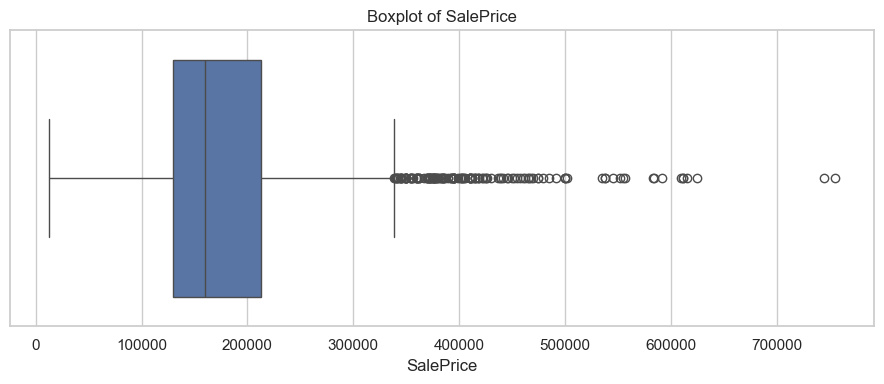

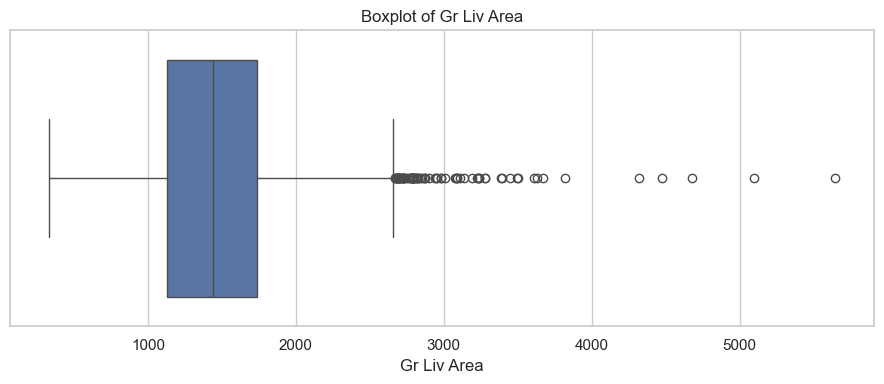

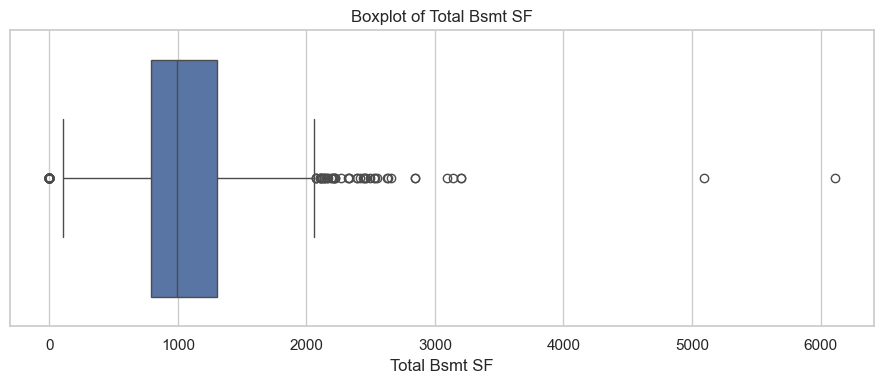

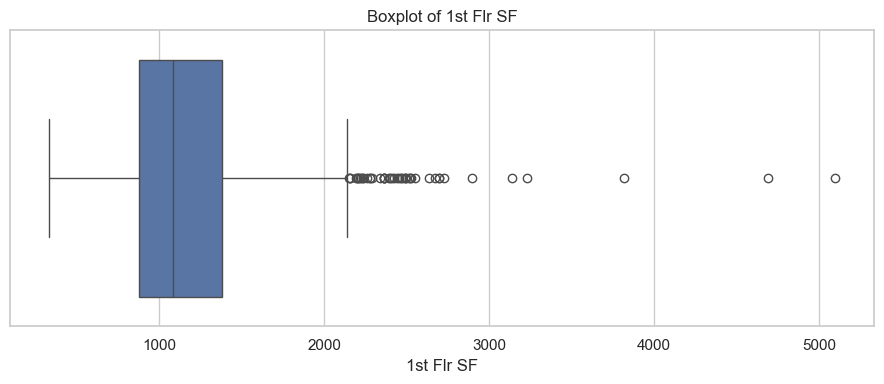

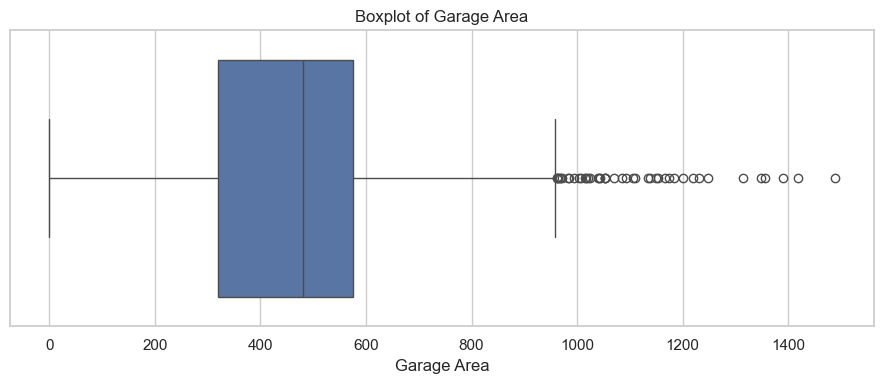

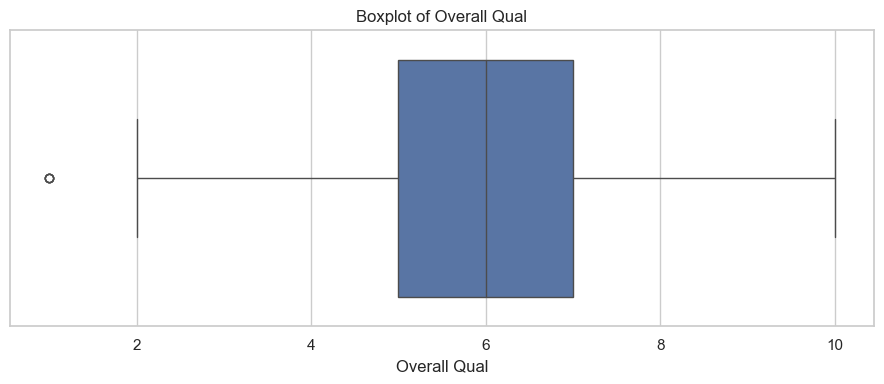

In [11]:
boxplot_cols = [
    "SalePrice", "Gr Liv Area", "Total Bsmt SF",
    "1st Flr SF", "Garage Area", "Overall Qual"
]

for col in boxplot_cols:
    if col in df.columns:
        plt.figure(figsize=(9, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

## 7. Z-score check

A Z-score tells us how far a value is from the average in terms of standard deviations. For this project, values with an absolute Z-score greater than 3 will be flagged as potential outliers.

This is only a screening method. We are not deleting every row that crosses the threshold.

In [12]:
zscore_cols = [
    "SalePrice", "Gr Liv Area", "Total Bsmt SF",
    "1st Flr SF", "Garage Area"
]

zscore_summary = []

for col in zscore_cols:
    if col in df.columns:
        values = df[col].astype(float)
        z = (values - values.mean()) / values.std(ddof=0)
        count = int((z.abs() > 3).sum())
        zscore_summary.append({
            "Column": col,
            "Potential Outliers (|Z| > 3)": count
        })

zscore_summary = pd.DataFrame(zscore_summary)
display(zscore_summary)

,Column,Potential Outliers (|Z| > 3)
0,SalePrice,48
1,Gr Liv Area,27
2,Total Bsmt SF,22
3,1st Flr SF,31
4,Garage Area,17


## 8. Inspect some potential outliers

Rather than removing the flagged rows immediately, we can inspect the most extreme observations. This helps separate unusual but believable houses from values that look like possible data-entry problems.

In [13]:
if "SalePrice" in df.columns and "Gr Liv Area" in df.columns:
    sale_z = (df["SalePrice"] - df["SalePrice"].mean()) / df["SalePrice"].std(ddof=0)
    area_z = (df["Gr Liv Area"] - df["Gr Liv Area"].mean()) / df["Gr Liv Area"].std(ddof=0)

    possible_outliers = df.loc[
        (sale_z.abs() > 3) | (area_z.abs() > 3),
        ["Order", "SalePrice", "Gr Liv Area", "Overall Qual", "Year Built"]
    ].copy()

    display(possible_outliers.sort_values("SalePrice", ascending=False).head(15))

,Order,SalePrice,Gr Liv Area,Overall Qual,Year Built
1767,1768,755000,4316,10,1994
1760,1761,745000,4476,10,1996
2445,2446,625000,3627,10,1995
1063,1064,615000,2470,10,2003
2974,45,611657,2364,9,2009
44,45,611657,2364,9,2009
432,433,610000,2674,10,2007
1637,1638,591587,2338,9,2006
2450,2451,584500,3500,9,1993
433,434,582933,2822,9,2008


## 9. Cleaning decision

For this stage, the potential outliers are kept in the dataset unless there is clear evidence that a value is incorrect. The purpose of Week 3 is to identify and understand unusual observations, not to remove data just because it is extreme.

This also gives us a cleaner starting point for the Week 4 EDA, where the distributions and relationships between variables will be explored in more detail.

In [14]:
print("Final dataset shape:", df.shape)
print("Total remaining missing values:", int(df.isna().sum().sum()))

display(df.head())

Final dataset shape: (3130, 82)
Total remaining missing values: 0


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,50.0,RL,68.0,31770,Pave,None,IR1,Lvl,...,0,None,None,None,0,5,2010,WD,Normal,215000
1,2,526350040,20.0,RH,80.0,11622,Pave,None,Reg,Lvl,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
2,3,526351010,20.0,RL,81.0,14267,Pave,None,IR1,Lvl,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20.0,RL,93.0,11160,Pave,None,Reg,Lvl,...,0,None,None,None,0,4,2010,WD,Normal,244000
4,5,527105010,60.0,RL,74.0,13830,Pave,None,IR1,Lvl,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900


## 10. Save the cleaned dataset

The cleaned data is saved as a new CSV so the original dataset stays untouched. This cleaned file can be used as the starting point for the next stage of the project.

In [15]:
output_file = "AmesHousing_Uncleaned_Cleaned.csv"
df.to_csv(output_file, index=False)

print(f"Saved cleaned dataset as: {output_file}")

Saved cleaned dataset as: AmesHousing_Uncleaned_Cleaned.csv
